In [ ]:
import os
import gc
import mne
import numpy as np
import multiprocessing

# --- Paths and setup ---
base_path = os.path.join(os.getcwd(), 'brain')
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('sub-')])[:40]
tasks = ['med1breath', 'med2', 'think1', 'think2']
batch_size = 5  # Number of parallel processes

# --- Function to load, filter, and save EEG data ---
def process_subject(subject):
    print(f"\n🚀 Processing Subject: {subject}")

    for task in tasks:
        eeg_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_eeg.bdf')

        if not os.path.exists(eeg_file):
            print(f"⚠️ Missing file: {eeg_file}")
            continue

        print(f"📥 Loading {eeg_file}")
        raw = mne.io.read_raw_bdf(eeg_file, preload=True)

        # Apply bandpass filter (0.5 - 40 Hz) with FIR (faster)
        raw.filter(l_freq=0.5, h_freq=40, method='fir', fir_design='firwin')

        # Apply notch filter (50 Hz) efficiently
        raw.notch_filter(freqs=50, method='fir')

        # Save the filtered file and free memory
        output_path = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_filtered.fif')
        raw.save(output_path, overwrite=True)
        print(f"✅ Saved filtered data: {output_path}")

        # Free memory
        del raw
        gc.collect()

# --- Parallel Processing ---
if __name__ == '__main__':
    with multiprocessing.Pool(processes=batch_size) as pool:
        pool.map(process_subject, subjects)

    print("\n✅ Finished processing all subjects efficiently.")



🚀 Processing Subject: sub-001
🚀 Processing Subject: sub-003
🚀 Processing Subject: sub-007
🚀 Processing Subject: sub-005



🚀 Processing Subject: sub-009

📥 Loading /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-003/eeg/sub-003_task-med1breath_eeg.bdf📥 Loading /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med1breath_eeg.bdf
📥 Loading /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-009/eeg/sub-009_task-med1breath_eeg.bdf

📥 Loading /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-005/eeg/sub-005_task-med1breath_eeg.bdf📥 Loading /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-007/eeg/sub-007_task-med1breath_eeg.bdf

Extracting EDF parameters from /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-003/eeg/sub-003_task-med1breath_eeg.bdf...
BDF f

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.6s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.7s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.4s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    2.5s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.6s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.3s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    3.5s
[Parallel(n_jobs=1)]: Do

# **Data Cleaning**

**ICA for removing Artifacts**

In [ ]:
import os
import gc
import mne
import joblib  # Faster parallel processing

# --- Paths and setup ---
base_path = os.path.join(os.getcwd(), 'brain')
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('sub-')])[:40]
tasks = ['med1breath', 'med2', 'think1', 'think2']
batch_size = 2  # Optimize for memory efficiency

# --- Function to Detect EOG Channel ---
def get_eog_channel(raw):
    """Detects EOG channel automatically. Returns the first available EOG channel name or None."""
    eog_chs = mne.pick_types(raw.info, eog=True, meg=False, eeg=False)
    if len(eog_chs) > 0:
        return raw.ch_names[eog_chs[0]]  # Return first detected EOG channel

    # If no EOG channels are present, check common frontal electrodes (Fp1, Fp2)
    common_eog_chs = ['Fp1', 'Fp2', 'VEOG', 'HEOG']
    for ch in common_eog_chs:
        if ch in raw.ch_names:
            return ch  # Return first found frontal electrode

    return None  # No EOG-related channels found

# --- Function to apply ICA ---
def apply_ica(subject):
    print(f"\n🚀 Processing ICA for Subject: {subject}")

    for task in tasks:
        filtered_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_filtered.fif')
        cleaned_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_ica_cleaned.fif')

        if not os.path.exists(filtered_file):
            print(f"⚠️ Missing file: {filtered_file}")
            continue

        if os.path.exists(cleaned_file):
            print(f"✅ ICA already applied, skipping: {cleaned_file}")
            continue

        print(f"📥 Loading FILTERED EEG for ICA: {filtered_file}")
        raw = mne.io.read_raw_fif(filtered_file, preload=False)  # Avoid full memory load
        raw.load_data()  # Load only when needed

        # Detect the best available EOG channel
        eog_channel = get_eog_channel(raw)
        if not eog_channel:
            print(f"⚠️ No EOG channels found for {subject} - {task}. Skipping ICA.")
            continue  # Skip ICA if no valid EOG channels

        print(f"🔍 Using EOG channel: {eog_channel}")

        # Set reduced ICA components
        n_components = min(10, len(raw.ch_names) - 1)

        # Create ICA object with `fastica` (faster than default)
        ica = mne.preprocessing.ICA(n_components=n_components, method='fastica', random_state=97, max_iter=200)

        print(f"🔧 Applying ICA for {subject} - {task}...")
        ica.fit(raw)  # Fit ICA

        # Detect and remove eye blink artifacts (EOG)
        eog_indices, _ = ica.find_bads_eog(raw, ch_name=eog_channel)
        print(f"💥 Detected EOG artifact components: {eog_indices}")

        # Remove detected artifacts
        ica.exclude = eog_indices
        ica.apply(raw)  # Modify raw in-place

        # Save ICA-cleaned EEG data
        raw.save(cleaned_file, overwrite=True)

        print(f"✅ ICA-cleaned data saved: {cleaned_file}")

        # Free memory
        del raw, ica
        gc.collect()

# --- Parallel Processing with `joblib` ---
if __name__ == '__main__':
    joblib.Parallel(n_jobs=batch_size)(
        joblib.delayed(apply_ica)(subject) for subject in subjects
    )

    print("\n✅ Finished ICA artifact removal for all subjects.")



🚀 Processing ICA for Subject: sub-001
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med1breath_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med2_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think1_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think2_ica_cleaned.fif

🚀 Processing ICA for Subject: sub-003
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-003/eeg/sub-003_task-med1breath_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/

**Normalization**

In [ ]:
import os
import gc
import mne
import numpy as np
from sklearn.preprocessing import StandardScaler

# --- Paths and setup ---
base_path = os.path.join(os.getcwd(), 'brain')
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('sub-')])[:40]
tasks = ['med1breath', 'med2', 'think1', 'think2']

# --- Function to Normalize EEG Data ---
def normalize_eeg(subject):
    print(f"\n🚀 Processing Normalization for Subject: {subject}")

    for task in tasks:
        cleaned_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_ica_cleaned.fif')
        normalized_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_normalized.fif')

        if not os.path.exists(cleaned_file):
            print(f"⚠️ Missing file: {cleaned_file}")
            continue

        if os.path.exists(normalized_file):
            print(f"✅ Normalized EEG already exists, skipping: {normalized_file}")
            continue

        print(f"📥 Loading ICA-cleaned EEG for normalization: {cleaned_file}")
        raw = mne.io.read_raw_fif(cleaned_file, preload=False)  # Avoid full memory load
        raw.load_data()

        # --- Downsample to Reduce Memory Usage ---
        raw.resample(128)  # 4x smaller data

        # --- Normalize Data in Chunks (Efficient Memory Handling) ---
        scaler = StandardScaler()
        chunk_size = 5000  # Process in chunks of 5000 samples
        for i in range(0, raw.n_times, chunk_size):
            chunk = raw.get_data(start=i, stop=i + chunk_size)
            chunk = (chunk - np.mean(chunk, axis=1, keepdims=True)) / np.std(chunk, axis=1, keepdims=True)
            raw._data[:, i:i + chunk_size] = chunk  # Update data in-place

        # --- Save Normalized EEG in Compressed Format ---
        raw.save(normalized_file, overwrite=True, fmt='double')

        print(f"✅ Normalized EEG data saved: {normalized_file}")

        # Free memory
        del raw, chunk, scaler
        gc.collect()

# --- Sequential Processing (Avoids File Conflicts) ---
if __name__ == '__main__':
    for subject in subjects:
        normalize_eeg(subject)

    print("\n✅ Finished Normalizing EEG for all subjects.")



🚀 Processing Normalization for Subject: sub-001
✅ Normalized EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med1breath_normalized.fif
✅ Normalized EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med2_normalized.fif
✅ Normalized EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think1_normalized.fif
✅ Normalized EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think2_normalized.fif

🚀 Processing Normalization for Subject: sub-002
✅ Normalized EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-002/eeg/sub-002_task-med1breath_normalized.fif
✅ Normalized EEG already exists, ski

In [ ]:
import os
import gc
import mne
import joblib  # Faster parallel processing

# --- Paths and setup ---
base_path = os.path.join(os.getcwd(), 'brain')
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('sub-')])[:40]
tasks = ['med1breath', 'med2', 'think1', 'think2']
batch_size = 1  # Lower batch size to prevent high memory usage

# --- Define Epoch Parameters ---
epoch_length = 2.0  # Length of each epoch in seconds
overlap = 0.25  # Reduce overlap to minimize redundant data

# --- Function to Segment EEG Data ---
def segment_eeg(subject):
    print(f"\n🚀 Processing Segmentation for Subject: {subject}")

    for task in tasks:
        normalized_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_normalized.fif')
        segmented_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_epochs.fif')

        if not os.path.exists(normalized_file):
            print(f"⚠️ Missing file: {normalized_file}")
            continue

        if os.path.exists(segmented_file):
            print(f"✅ Segmented EEG already exists, skipping: {segmented_file}")
            continue

        print(f"📥 Loading Normalized EEG for segmentation: {normalized_file}")
        raw = mne.io.read_raw_fif(normalized_file, preload=False)  # Avoid full data loading

        # Downsample to 128 Hz to reduce data size (4x smaller)
        raw.load_data()
        raw.resample(128)

        # Define epoching parameters
        sfreq = raw.info['sfreq']  # Sampling frequency (now 128 Hz)
        events = mne.make_fixed_length_events(raw, id=1, start=0, stop=None, duration=epoch_length, overlap=overlap)

        # Create overlapping epochs
        epochs = mne.Epochs(raw, events, event_id=1, tmin=0, tmax=epoch_length, baseline=None, detrend=1, preload=True)

        # Save segmented EEG in compressed format
        epochs.save(segmented_file, overwrite=True, fmt='single')

        print(f"✅ Segmented EEG data saved: {segmented_file}")

        # Free memory
        del raw, epochs
        gc.collect()

# --- Parallel Processing with `joblib` ---
if __name__ == '__main__':
    joblib.Parallel(n_jobs=batch_size)(
        joblib.delayed(segment_eeg)(subject) for subject in subjects
    )

    print("\n✅ Finished EEG segmentation for all subjects.")



🚀 Processing Segmentation for Subject: sub-001
✅ Segmented EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med1breath_epochs.fif
✅ Segmented EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-med2_epochs.fif
✅ Segmented EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think1_epochs.fif
✅ Segmented EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think2_epochs.fif

🚀 Processing Segmentation for Subject: sub-002
✅ Segmented EEG already exists, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-002/eeg/sub-002_task-med1breath_epochs.fif
✅ Segmented EEG already exists, skipping: /mnt/batch/tasks/shar

**Baseline Corrector**

In [ ]:
import os
import gc
import mne
import numpy as np
import pandas as pd
import joblib  # Faster parallel processing

# --- Paths and setup ---
base_path = os.path.join(os.getcwd(), 'brain')
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('sub-')])[:40]
tasks = ['med1breath', 'med2', 'think1', 'think2']

# --- Define EEG frequency bands ---
freq_bands = {
    'Delta': (0.5, 4),
    'Theta': (4, 8),
    'Alpha': (8, 12),
    'Beta': (12, 30),
    'Gamma': (30, 50)
}

# ✅ **Baseline Period (First 200ms of each epoch)**
baseline_period = (0, 0.2)

# --- Function to Apply Baseline Correction & Compute PSD ---
def process_eeg(subject):
    print(f"\n🚀 Processing Baseline & PSD for Subject: {subject}")

    psd_data = []  # Store computed features before writing to CSV

    for task in tasks:
        epochs_file = os.path.join(base_path, subject, 'eeg', f'{subject}_task-{task}_epochs.fif')

        if not os.path.exists(epochs_file):
            print(f"⚠️ Missing file: {epochs_file}")
            continue

        print(f"📥 Loading EEG epochs for processing: {epochs_file}")
        epochs = mne.read_epochs(epochs_file, preload=False)  # Lazy loading for memory efficiency

        # Load only required data
        epochs.load_data()

        # --- Get Sampling Frequency & Adjust fmax if Needed ---
        sfreq = epochs.info['sfreq']
        max_freq = min(50, sfreq / 2)  # Ensure fmax does not exceed Nyquist limit

        # --- Apply Baseline Correction ---
        print(f"🛠️ Applying Baseline Correction for {subject} - {task}...")
        epochs.apply_baseline(baseline_period)

        # --- Compute PSD using Welch’s method ---
        print(f"📊 Computing PSD for {subject} - {task}...")
        psds = epochs.compute_psd(method='welch', fmin=0.5, fmax=max_freq, n_fft=128)  # Increased n_fft for better resolution
        psd_values = psds.get_data()
        freqs = psds.freqs

        # Ensure valid frequency bins exist
        if len(freqs) == 0:
            print(f"⚠️ No valid frequencies found for {subject} - {task}. Skipping.")
            continue

        # Extract mean power for each frequency band
        psd_mean = {band: psd_values[:, :, (freqs >= fmin) & (freqs <= fmax)].mean(axis=1).mean()
                    for band, (fmin, fmax) in freq_bands.items() if fmax <= max_freq}  # Only include valid bands

        # Append results to list
        psd_data.append({'Subject': subject, 'Task': task, **psd_mean})

        # Free memory
        del epochs, psds, psd_values, freqs
        gc.collect()

    # ✅ **Write Features to CSV in a Single Operation**
    if psd_data:
        csv_path = os.path.join(base_path, 'psd_features.csv')
        pd.DataFrame(psd_data).to_csv(csv_path, mode='a', header=not os.path.exists(csv_path), index=False)

# --- Parallel Processing with `joblib` (Faster than multiprocessing) ---
if __name__ == '__main__':
    joblib.Parallel(n_jobs=4)(  # Adjust based on CPU power
        joblib.delayed(process_eeg)(subject) for subject in subjects
    )

    print("\n✅ Finished Baseline Correction & PSD Extraction for all subjects.")


✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-022/eeg/sub-022_task-think1_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-022/eeg/sub-022_task-think2_ica_cleaned.fif

🚀 Processing ICA for Subject: sub-023
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-023/eeg/sub-023_task-med1breath_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-023/eeg/sub-023_task-med2_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-023/eeg/sub-023_task-think1_ica_cleaned.fif
✅ ICA already applied, skipping: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-023/eeg/sub-023_task-thin

/tmp/ipykernel_3119/3202772839.py:64: RuntimeWarning: Mean of empty slice.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3119/3202772839.py:39: RuntimeWarning: This filename (/mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/sub-001/eeg/sub-001_task-think1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
/tmp/ipykernel_3119/3202772839.py:64: RuntimeWarning: Mean of empty slice.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3119/3202772839.py:64: RuntimeWarning: Mean of empty slice.
/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/numpy/core/_meth

📥 Loading PSD features from: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/psd_features.csv


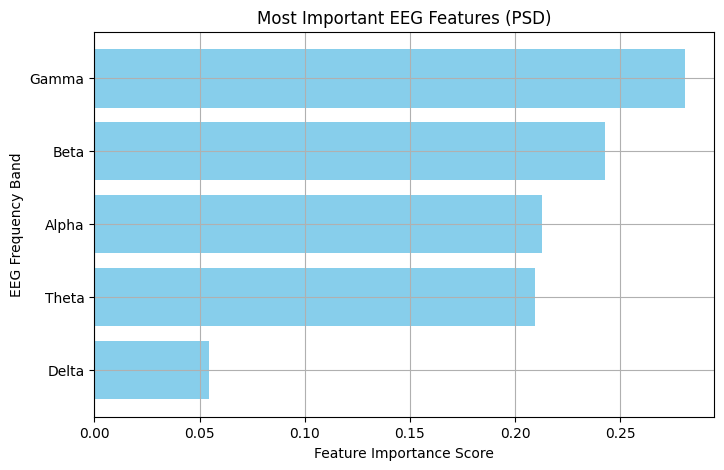


🔍 Top EEG Features Based on Importance:
  Feature  Importance
4   Gamma    0.280543
3    Beta    0.242573
2   Alpha    0.212833
1   Theta    0.209382
0   Delta    0.054668


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# --- Load PSD Features ---
base_path = os.path.join(os.getcwd(), 'brain')
csv_path = os.path.join(base_path, 'psd_features.csv')

if not os.path.exists(csv_path):
    print(f"⚠️ PSD feature file not found: {csv_path}")
else:
    print(f"📥 Loading PSD features from: {csv_path}")

# Read the CSV
psd_df = pd.read_csv(csv_path)

# --- Encode Task Labels ---
label_encoder = LabelEncoder()
psd_df['Task'] = label_encoder.fit_transform(psd_df['Task'])  # Convert task labels to numbers

# Define features (Delta, Theta, Alpha, Beta, Gamma) and target (Task)
X = psd_df.drop(columns=['Subject', 'Task'])  # EEG frequency bands
y = psd_df['Task']  # Task label

# Split dataset into training and testing (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Train a Random Forest Model ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- Extract Feature Importance ---
feature_importance = rf_model.feature_importances_

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# --- Plot Feature Importance ---
plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("EEG Frequency Band")
plt.title("Most Important EEG Features (PSD)")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.grid()
plt.show()

# Print top features
print("\n🔍 Top EEG Features Based on Importance:")
print(feature_importance_df)


📥 Loading PSD features from: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/psd_features.csv
Unique task labels before encoding: ['med1breath' 'med2' 'think1' 'think2']
✅ Trained model saved as: /mnt/batch/tasks/shared/LS_root/mounts/clusters/poojash1/code/Users/poojash/brain/rf_model_20250316_210418.pkl

🔍 Model Accuracy: 0.8581

📊 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88        37
           1       0.91      0.81      0.86        37
           2       0.84      0.86      0.85        37
           3       0.84      0.84      0.84        37

    accuracy                           0.86       148
   macro avg       0.86      0.86      0.86       148
weighted avg       0.86      0.86      0.86       148



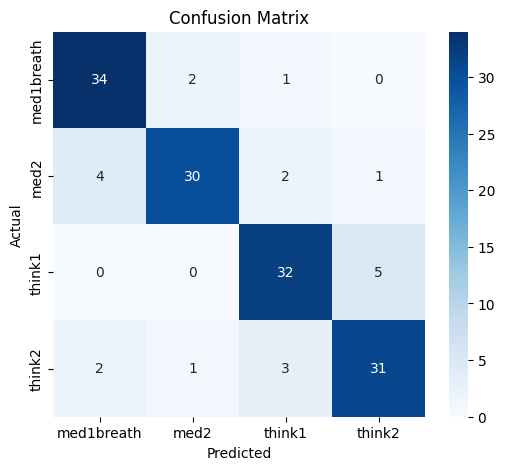

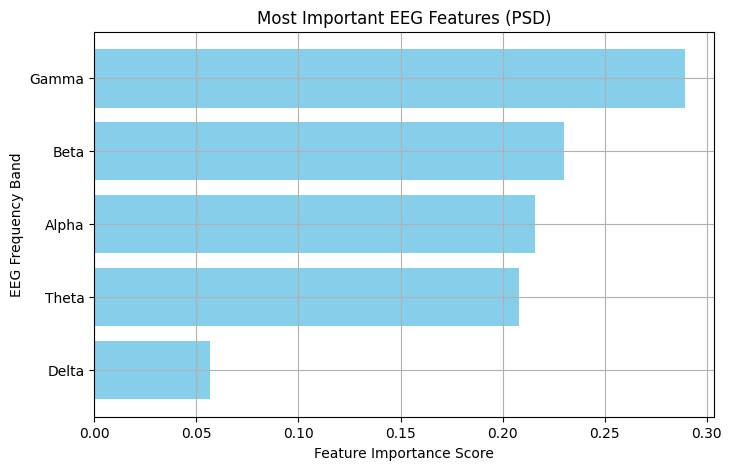


🔍 Top EEG Features Based on Importance:
  Feature  Importance
4   Gamma    0.289174
3    Beta    0.230193
2   Alpha    0.215883
1   Theta    0.207956
0   Delta    0.056793


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datetime import datetime

# --- Load EEG PSD Features ---
base_path = os.path.join(os.getcwd(), 'brain')
csv_path = os.path.join(base_path, 'psd_features.csv')

if not os.path.exists(csv_path):
    print(f"⚠️ PSD feature file not found: {csv_path}")
    exit()

print(f"📥 Loading PSD features from: {csv_path}")
psd_df = pd.read_csv(csv_path)

# --- Encode Task Labels ---
print(f"Unique task labels before encoding: {psd_df['Task'].unique()}")
label_encoder = LabelEncoder()
psd_df['Task'] = label_encoder.fit_transform(psd_df['Task'])

# Define features and target
X = psd_df.drop(columns=['Subject', 'Task'])
y = psd_df['Task']

# --- Split Data First (Prevent Data Leakage) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Normalize Features After Splitting ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- Train Random Forest Model with Optimized Hyperparameter Search ---
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, n_iter=5, cv=3, n_jobs=-1)
rf_model.fit(X_train, y_train)
best_rf = rf_model.best_estimator_

# --- Save the Trained Model with a Timestamp ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(base_path, f'rf_model_{timestamp}.pkl')
joblib.dump(best_rf, model_path)

print(f"✅ Trained model saved as: {model_path}")

# --- Model Evaluation ---
y_pred = best_rf.predict(X_test)
print(f"\n🔍 Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# --- Confusion Matrix Visualization ---
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# --- Feature Importance Visualization ---
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': best_rf.feature_importances_})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("EEG Frequency Band")
plt.title("Most Important EEG Features (PSD)")
plt.gca().invert_yaxis()
plt.grid()
plt.show()

print("\n🔍 Top EEG Features Based on Importance:")
print(feature_importance_df)


SVM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

# ✅ --- Load EEG Data ---
features = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
X = psd_df[features].copy()
y = psd_df['Task'].copy()

# ✅ --- Add More EEG Features ---
X['Theta/Beta'] = X['Theta'] / (X['Beta'] + 1e-5)
X['Alpha/Beta'] = X['Alpha'] / (X['Beta'] + 1e-5)
X['Gamma/Beta'] = X['Gamma'] / (X['Beta'] + 1e-5)

# ✅ --- Handle NaN and Infinite Values ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# ✅ --- Standardize Data for SVM ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ --- Feature Selection (Keep the 5 Best Features) ---
selector = SelectKBest(f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

# ✅ --- Dimensionality Reduction using PCA ---
pca = PCA(n_components=4)  # Keep top 4 PCA components
X_pca = pca.fit_transform(X_selected)

# ✅ --- Encode Labels ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ✅ --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# ✅ --- Hyperparameter Tuning for SVM ---
svm = SVC()
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],  # Regularization parameter
    'kernel': ['rbf', 'poly', 'sigmoid'],  # Try different kernels
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]  # Kernel coefficient
}

grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# ✅ --- Train Optimized SVM Model ---
best_svm = grid_search.best_estimator_
best_svm.fit(X_train, y_train)

# ✅ --- Evaluate Model ---
y_pred = best_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# ✅ --- Print Best Parameters & Final Accuracy ---
print(f"Best SVM Parameters: {grid_search.best_params_}")
print(f"Final Accuracy: {accuracy * 100:.2f}%")


Best SVM Parameters: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}
Final Accuracy: 82.43%


Random Forest

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

# ✅ --- Load EEG Data ---
features = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
X = psd_df[features].copy()
y = psd_df['Task'].copy()

# ✅ --- Add More EEG Features ---
X['Theta/Beta'] = X['Theta'] / (X['Beta'] + 1e-5)
X['Alpha/Beta'] = X['Alpha'] / (X['Beta'] + 1e-5)
X['Gamma/Beta'] = X['Gamma'] / (X['Beta'] + 1e-5)

# ✅ --- Handle NaN and Infinite Values ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# ✅ --- Standardize Data for Random Forest ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ --- Feature Selection (Keep the 5 Best Features) ---
selector = SelectKBest(f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

# ✅ --- Dimensionality Reduction using PCA ---
pca = PCA(n_components=4)  # Keep top 4 PCA components
X_pca = pca.fit_transform(X_selected)

# ✅ --- Encode Labels ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ✅ --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# ✅ --- Hyperparameter Tuning for Random Forest ---
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [None, 10, 20],  # Depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4]  # Minimum samples per leaf
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# ✅ --- Train Optimized Random Forest Model ---
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)

# ✅ --- Evaluate Model ---
y_pred = best_rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# ✅ --- Print Best Parameters & Final Accuracy ---
print(f"Best Random Forest Parameters: {grid_search.best_params_}")
print(f"Final Accuracy: {accuracy * 100:.2f}%")


Best Random Forest Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Final Accuracy: 86.49%


XGBoost

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

# ✅ --- Load EEG Data ---
features = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
X = psd_df[features].copy()
y = psd_df['Task'].copy()

# ✅ --- Add More EEG Features ---
X['Theta/Beta'] = X['Theta'] / (X['Beta'] + 1e-5)
X['Alpha/Beta'] = X['Alpha'] / (X['Beta'] + 1e-5)
X['Gamma/Beta'] = X['Gamma'] / (X['Beta'] + 1e-5)

# ✅ --- Handle NaN and Infinite Values ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# ✅ --- Standardize Data for XGBoost ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ --- Feature Selection (Keep the 5 Best Features) ---
selector = SelectKBest(f_classif, k=5)
X_selected = selector.fit_transform(X_scaled, y)

# ✅ --- Dimensionality Reduction using PCA ---
pca = PCA(n_components=4)  # Keep top 4 PCA components
X_pca = pca.fit_transform(X_selected)

# ✅ --- Encode Labels ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ✅ --- Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X_pca, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# ✅ --- Hyperparameter Tuning for XGBoost ---
xgb = XGBClassifier(objective='multi:softmax', eval_metric='mlogloss', random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinkage
    'max_depth': [3, 5, 7],  # Tree depth
    'subsample': [0.8, 1.0]  # Sample ratio
}

grid_search = GridSearchCV(xgb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# ✅ --- Train Optimized XGBoost Model ---
best_xgb = grid_search.best_estimator_
best_xgb.fit(X_train, y_train)

# ✅ --- Evaluate Model ---
y_pred = best_xgb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# ✅ --- Print Best Parameters & Final Accuracy ---
print(f"Best XGBoost Parameters: {grid_search.best_params_}")
print(f"Final Accuracy: {accuracy * 100:.2f}%")


Best XGBoost Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Final Accuracy: 85.81%


LSTM

In [ ]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC

# ✅ --- Ignore Warnings ---
warnings.filterwarnings("ignore")

# ✅ --- Load EEG Data ---
features = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
X = psd_df[features].copy()
y = psd_df['Task'].copy()

# ✅ --- Add More EEG Features ---
X['Theta/Beta'] = X['Theta'] / (X['Beta'] + 1e-5)
X['Alpha/Beta'] = X['Alpha'] / (X['Beta'] + 1e-5)
X['Gamma/Beta'] = X['Gamma'] / (X['Beta'] + 1e-5)

# ✅ --- Handle NaN and Infinite Values ---
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

# ✅ --- Standardize Data (Fix LightGBM Feature Name Warning) ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)  # Keep feature names

# ✅ --- Encode Labels ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# ✅ --- Split Data (70% Train, 30% Test) ---
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# ✅ --- Define Models ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3),
    "LightGBM": LGBMClassifier(n_estimators=100, learning_rate=0.1),
    "SVM (RBF Kernel)": SVC(kernel='rbf', C=1, gamma='scale')
}

# ✅ --- Train & Evaluate Each Model ---
results = {}
print("\n🔍 Model Performance on EEG Data:\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy * 100
    print(f"✅ {name}: {accuracy * 100:.2f}% accuracy")

# ✅ --- Print Best Model ---
best_model = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model} with {results[best_model]:.2f}% accuracy")



🔍 Model Performance on EEG Data:

✅ Logistic Regression: 25.68% accuracy
✅ KNN: 37.84% accuracy
✅ Gradient Boosting: 83.33% accuracy
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1165
[LightGBM] [Info] Number of data points in the train set: 518, number of used features: 8
[LightGBM] [Info] Start training from score -1.390163
[LightGBM] [Info] Start training from score -1.382441
[LightGBM] [Info] Start training from score -1.390163
[LightGBM] [Info] Start training from score -1.382441
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 